# Using Neural Networks to Predict Concrete Compresive Strength

In this notebook, we use a neural network to predict the compressive strength of concrete using the concrete's age and ingredients. The [Concrete Compressive Strength dataset](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength) comes from UC Irvine's Machine Learning Repository.

Concrete's compressive strength (measured in megapascals, MPa) is an important mechanical property for structural engineering, measuring how much load concrete can bear. A concrete mix's strength is determined by a complex, non-linear interaction between its ingredients and how long it has been curing.

This dataset contains 1,030 laboratory mixture records with 8 input variables (ingredient amounts in kg/m^3 plus curing age in days) and one continuous output (the 28-day compressive strength in MPa).

**Features:**
| **Feature** | **Type** | **Description** | **Units** |
|---|---|---|---|
| Cement | Continuous | Amount of cement | kg/m^3 |
| BlastFurnaceSlag | Integer | Supplementary cementitious material | kg/m^3 |
| FlyAsh | Continuous | Pozzolanic supplementary material | kg/m^3 |
| Water | Continuous |Water content | kg/m^3 |
| Superplasticizer | Continuous | Chemical admixture | kg/m^3 |
| CoarseAggregate | Continuous | Coarse aggregate (gravel/stone) | kg/m^3 |
| FineAggregate | Continuous | Fine aggregate (sand) | kg/m^3 |
| Age | Integer | Curing age | days |

**Target:** ConcreteCompressiveStrength — compressive strength (MPa, continuous real-valued)

---

## Load and Explore Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    NeuralNetwork,
    LinearRegression,
    StandardScaler,
    train_test_split,
    train_val_test_split,
    regression_metrics,
)

from ml_package.supervised_learning.neural_network import MSE

np.random.seed(42)

In [16]:
# Load data and assign features and target
df = pd.read_csv("Concrete_Data.csv")
X = df.drop(columns = "Concrete compressive strength")
y = df["Concrete compressive strength"]

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [18]:
# Descriptive statistics
print(f"Compressive Strength (MPa) — mean: {y.mean():.2f}, std: {y.std():.2f}, "
      f"range: [{y.min():.2f}, {y.max():.2f}]")
X.describe().round(3)

Compressive Strength (MPa) — mean: 35.82, std: 16.71, range: [2.33, 82.60]


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day)
count,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000
mean,281.168,73.896,54.188,181.567,6.205,972.919,773.580,45.662
std,104.506,86.279,63.997,21.354,5.974,77.754,80.176,63.170
min,102.000,0.000,0.000,121.800,0.000,801.000,594.000,1.000
25%,192.375,0.000,0.000,164.900,0.000,932.000,730.950,7.000
50%,272.900,22.000,0.000,185.000,6.400,968.000,779.500,28.000
75%,350.000,142.950,118.300,192.000,10.200,1029.400,824.000,56.000
max,540.000,359.400,200.100,247.000,32.200,1145.000,992.600,365.000


## Data Preprocessing

We use a three-way split (train/validation/test) so the neural network's generalization can be monitored on the validation set during training without leaking into the final test evaluation. The training set is used for gradient updates, the validation set for network architecture selection, and the test set for final predictions.

We also scale the data using `StandardScaler` to ensure stable gradients.

Additionally, the format of the data is important for `NeuralNetwork` to work (specifically the stochastic gradient descent method, `SGD`). To use the neural network, we must convert the NumPy arrays into a list of `(x_column_vector, y_scalar_vector)` tuples. This is done with the `to_nn_format` helper: each sample x is reshaped from a 1D array of length 8 to a (8×1) column vector, and the target y is wrapped in a (1×1) array. This format matches the network's internal matrix operations which expect column vectors for forward and backward passes

---

In [23]:
X_arr = X.values.astype(float)

# Three-way split: 70% train, 15% val, 15% test
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X_arr, y, val_size=0.15, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

# Format for NeuralNetwork: list of (x_col, y_col) tuples
def to_nn_format(X, y):
    return [(x.reshape(-1,1), np.array([[yi]]) ) for x, yi in zip(X, y)]

train_data = to_nn_format(X_train_s, y_train)
val_data   = to_nn_format(X_val_s,   y_val)
test_data  = to_nn_format(X_test_s,  y_test)

Train: 720  |  Val: 155  |  Test: 155


## Baseline Linear Regression

Before training the neural network we fit a linear regression model on the same training split to give us a baseline for comparison with our neural network. Both models see the same standardized features and are evaluated on the same test set, so any performance difference is attributable purely to the ability to learn non-linear relationships. 

The linear regression achieves an R-squared value of about 0.67. 

---

In [24]:
lr = LinearRegression()
lr.train(X_train_s, y_train, eta=0.05, epochs=3000)

y_pred_lr = lr.predict(X_test_s)
r2_lr  = regression_metrics.r_squared(y_test, y_pred_lr)
rmse_lr = regression_metrics.rmse(y_test, y_pred_lr)
print(f"Linear Regression baseline — R²: {r2_lr:.4f}   RMSE: {rmse_lr:.4f} MPa")

Linear Regression baseline — R²: 0.6696   RMSE: 9.4327 MPa


## Neural Network Architecture Definition and Training

We define the network with layer_sizes=[8, 64, 32, 1]: 8 input neurons (one per standardized feature), two hidden layers of 64 and 32 sigmoid units, and a single linear output neuron (since we are doing regression). Setting `task = "regression"` tells `NeuralNetwork` to use a linear output activation and default to MSE cost.

We print the total trainable parameter count: (8×64 + 64) + (64×32 + 32) + (32×1 + 1) = 512 + 64 + 2048 + 32 + 32 + 1 = 2,689 parameters. Training runs for 100 epochs with mini-batch size 32 and learning rate 0.01. Each epoch shuffles the 721 training samples, partitions them into mini-batches of 32 (yielding about 22 mini-batch updates per epoch), and runs forward-pass and backpropagation update cycles through each. The `validation_data` argument enables per-epoch validation MSE printing, which lets us visually monitor whether the gap between training and validation loss is growing (overfitting) or stable (good generalization).

In [25]:
n_features = X_train_s.shape[1]   # 8 input features

# Architecture: 8 → 64 → 32 → 1  (linear output for regression)
nn = NeuralNetwork(
    layer_sizes=[n_features, 64, 32, 1],
    cost=MSE(),
    task="regression"
)

print(f"Network architecture: {nn.layer_sizes}")
print(f"Total trainable parameters: "
      f"{sum(w.size for w in nn.weights) + sum(b.size for b in nn.biases)}")

print("\nTraining...")
nn.SGD(
    training_data=train_data,
    epochs=100,
    mini_batch_size=32,
    eta=0.01,
    validation_data=val_data,
    monitor_cost=False,
)

Network architecture: [8, 64, 32, 1]
Total trainable parameters: 2689

Training...
Epoch 1/100 — Validation MSE: 217.1428
Epoch 2/100 — Validation MSE: 181.3093
Epoch 3/100 — Validation MSE: 125.8594
Epoch 4/100 — Validation MSE: 98.6144
Epoch 5/100 — Validation MSE: 90.2146
Epoch 6/100 — Validation MSE: 94.9301
Epoch 7/100 — Validation MSE: 100.8740
Epoch 8/100 — Validation MSE: 86.0283
Epoch 9/100 — Validation MSE: 81.3570
Epoch 10/100 — Validation MSE: 75.3201
Epoch 11/100 — Validation MSE: 79.8780
Epoch 12/100 — Validation MSE: 69.1267
Epoch 13/100 — Validation MSE: 66.1483
Epoch 14/100 — Validation MSE: 59.8140
Epoch 15/100 — Validation MSE: 59.8028
Epoch 16/100 — Validation MSE: 56.2316
Epoch 17/100 — Validation MSE: 51.0363
Epoch 18/100 — Validation MSE: 58.4301
Epoch 19/100 — Validation MSE: 48.3100
Epoch 20/100 — Validation MSE: 42.9244
Epoch 21/100 — Validation MSE: 66.4592
Epoch 22/100 — Validation MSE: 40.6983
Epoch 23/100 — Validation MSE: 42.9822
Epoch 24/100 — Validation

## Evaluate the Network

The `nn_predict_regression` helper function runs `nn.feedforward(x.reshape(-1,1))` for each test sample and extracts the scalar output [0,0]. 

On the test set, the neural network achieves an R-squared value of about 0.87, which is substantially higher than the linear regression baseline of about 0.67. The RMSE drops to approximately 5.9 MPa, compared to 9.4 MPa for linear regression. This means the neural network's average prediction error is roughly half that of the linear model.

---

In [26]:
def nn_predict_regression(nn, X):
    """Run forward pass for all samples, return 1-D prediction array."""
    return np.array([nn.feedforward(x.reshape(-1,1))[0,0] for x in X])

y_pred_nn_test  = nn_predict_regression(nn, X_test_s)
y_pred_nn_train = nn_predict_regression(nn, X_train_s)

r2_nn   = regression_metrics.r_squared(y_test, y_pred_nn_test)
rmse_nn = regression_metrics.rmse(y_test, y_pred_nn_test)
mae_nn  = regression_metrics.mae(y_test, y_pred_nn_test)

print(f"  R²           : {r2_nn:.4f}   (vs. Linear Regression: {r2_lr:.4f})")
print(f"  RMSE         : {rmse_nn:.4f} MPa  (vs. Linear Regression: {rmse_lr:.4f})")
print(f"  MAE          : {mae_nn:.4f} MPa")
print(f"  SMAPE        : {regression_metrics.smape(y_test, y_pred_nn_test):.2f} %")


  R²           : 0.8728   (vs. Linear Regression: 0.6696)
  RMSE         : 5.8519 MPa  (vs. Linear Regression: 9.4327)
  MAE          : 4.2356 MPa
  SMAPE        : 13.41 %


---

A particularly informative plot is a histogram showing both the neural network and linear regression model residuals. This shows that the neural network's residuals have a noticeably tighter, more symmetric distribution centred on zero.

---

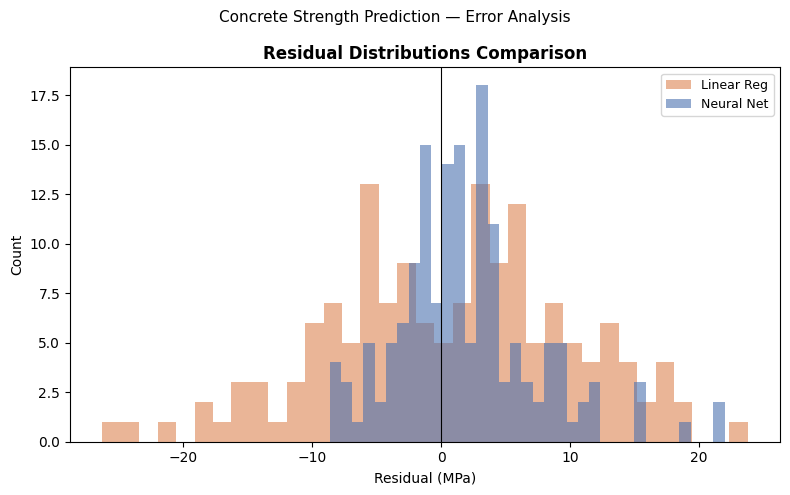

In [29]:
# Residual histograms for the neural network and linear regression model
# Setup a single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Calculate residuals (ensure res_nn is defined)
res_nn = y_test - y_pred_nn_test
res_lr = y_test - y_pred_lr

# Plot the histogram comparison directly on ax
ax.hist(res_lr, bins=35, alpha=0.6, color="#DD8452", label="Linear Reg")
ax.hist(res_nn, bins=35, alpha=0.6, color="#4C72B0", label="Neural Net")

# Styling and labels
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Count")
ax.set_title("Residual Distributions Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Adding the main title from the original suptitle
plt.suptitle("Concrete Strength Prediction — Error Analysis", fontsize=11)
plt.tight_layout()
plt.show()


---

Overall, the neural network's ability to learn non-linear relationships between features and the target greatly improve the regression model's performance over a linear model. 

---